In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import hubble_fit
from hubble_fit import z_agn_pivot
from hubble_fit import *

In [24]:
df_agn, df_pantheon, _sna_LogdetCov, _sna_L, _sna_Lower = hubble_fit.load_data("results/data/aug17/aug17b_chisq_nobwb_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False)


Loading quasar data...


Reading quasars from HDF5: 100%|██████████| 7320/7320 [00:22<00:00, 322.99it/s]


Number of quasars loaded: 7320
Length of colin_df: 13270
Number with apparent_mag_2500 > 0: 11050
Length of merged DataFrame: 7320
object_id not in merged: []
Number of quasars with 0 < z <= 1.0: 1776
Number of quasars with z > 3: 207
Highest redshift quasar: 4.455935435869128
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err']
Cut on alpha_lambda: 384 objects removed
Cut on redchi: 26 objects removed
Cut on apparent_mag_2500: 1240 objects removed
Cut on apparent_mag_i: 57 objects removed
Total objects removed by all cuts: 1652
Number of quasars with 0 < z <= 1.0: 1227
Number of dropped quasars with 0 < z <= 1.0: 549
Number of quasars with z > 3: 201
Final number of quasars: 5668
Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Cholesky factorization successful. Data loaded. 


In [27]:
import hubble_fit
cosmo_model = 'Flatw0waCDM'
sampler, flat_samples, labels, mag_corr, logZ, logZerr = hubble_fit.run_mcmc_pipeline(df_agn, df_pantheon, cosmo_model=cosmo_model,
                                                                                      completeness=True, use_full_cov=True, speed="test",
                                                                                      #resume="results/hubble/dynesty_checkpoint_Flatw0waCDM_joint_production_backup.save")
                                                                                      resume="results/dynesty_backup/dynesty_checkpoint_Flatw0waCDM_joint_test.save")

Running sampling with 12 parameters for cosmological model: Flatw0waCDM
Pivot point for x: 20.243724822998047
Scatter in m_2500 - m_i fit (std of residuals): 0.45
Using mag range: 16.00 to 26.00
log tau UV RF mean: 2.7231
log tau UV RF pivot (weighted): 2.6158
log sigma0 mean: -0.7300
log sigma0 pivot (weighted): -0.7217
z mean: 1.625, calculated z pivot: 1.528
Checkpoint file: results/hubble/dynesty_checkpoint_Flatw0waCDM_joint_test.save
Resuming from checkpoint file: results/dynesty_backup/dynesty_checkpoint_Flatw0waCDM_joint_test.save
[Warning] Starting TEST run...

Bayesian evidence logZ = 49.73 ± 0.49

Highest-weight (posterior) sample:
  idx: 6927
  logl: 78.54247073339411
  weight: 0.001598513239105677
  (preview) integrals[:10]: [0.27025181 0.28353836 0.29068413 0.32995672 0.0676348  0.33050289
 0.47207431 0.27963624 0.41723839 0.26378945]


/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/dynesty/dynamicsampler.py:2046: RuntimeWarning: You tried to resume the run that has ended successfully.
This is not supported. No sampling was performed
  warnings.warn(



Posterior (equal-weight) blob summaries:
  per-object mean (first 10): [0.25769426 0.27074489 0.27840926 0.32006243 0.06711393 0.31883962
 0.46261252 0.26801978 0.40739424 0.24627396]
  per-object median (first 10): [0.25769144 0.27087343 0.27845327 0.31963917 0.06706896 0.31876646
 0.46243408 0.26818264 0.40713413 0.24615688]

Dynesty results stats:
  samples shape: (8002, 12)
  blobs shape: (8002, 5668)
  weights max: 0.001598513239105677
  effective samples (ESS): 983.7470791494843
  resampled samples shape: (8002, 12)
  resampled blobs shape: (8002, 5668)

Median parameters (equal-weight posterior):
[ 6.60713725e-03  1.03289234e-01 -1.92433258e+01 -2.14834221e+01
  4.52422242e+00 -1.67581128e+00  5.55729457e-01 -3.64776190e-01
  7.30001739e+01  6.06582004e-01 -1.18391115e+01 -1.82905833e+01]
       gamma_sn: 0.0066 (+0.0104, -0.0111)
         tau_Ms: 0.1033 (+0.0665, -0.0593)
          M0_sn: -19.2433 (+0.0263, -0.0282)
         M0_agn: -21.4834 (+0.0477, -0.0420)
      alpha_agn:

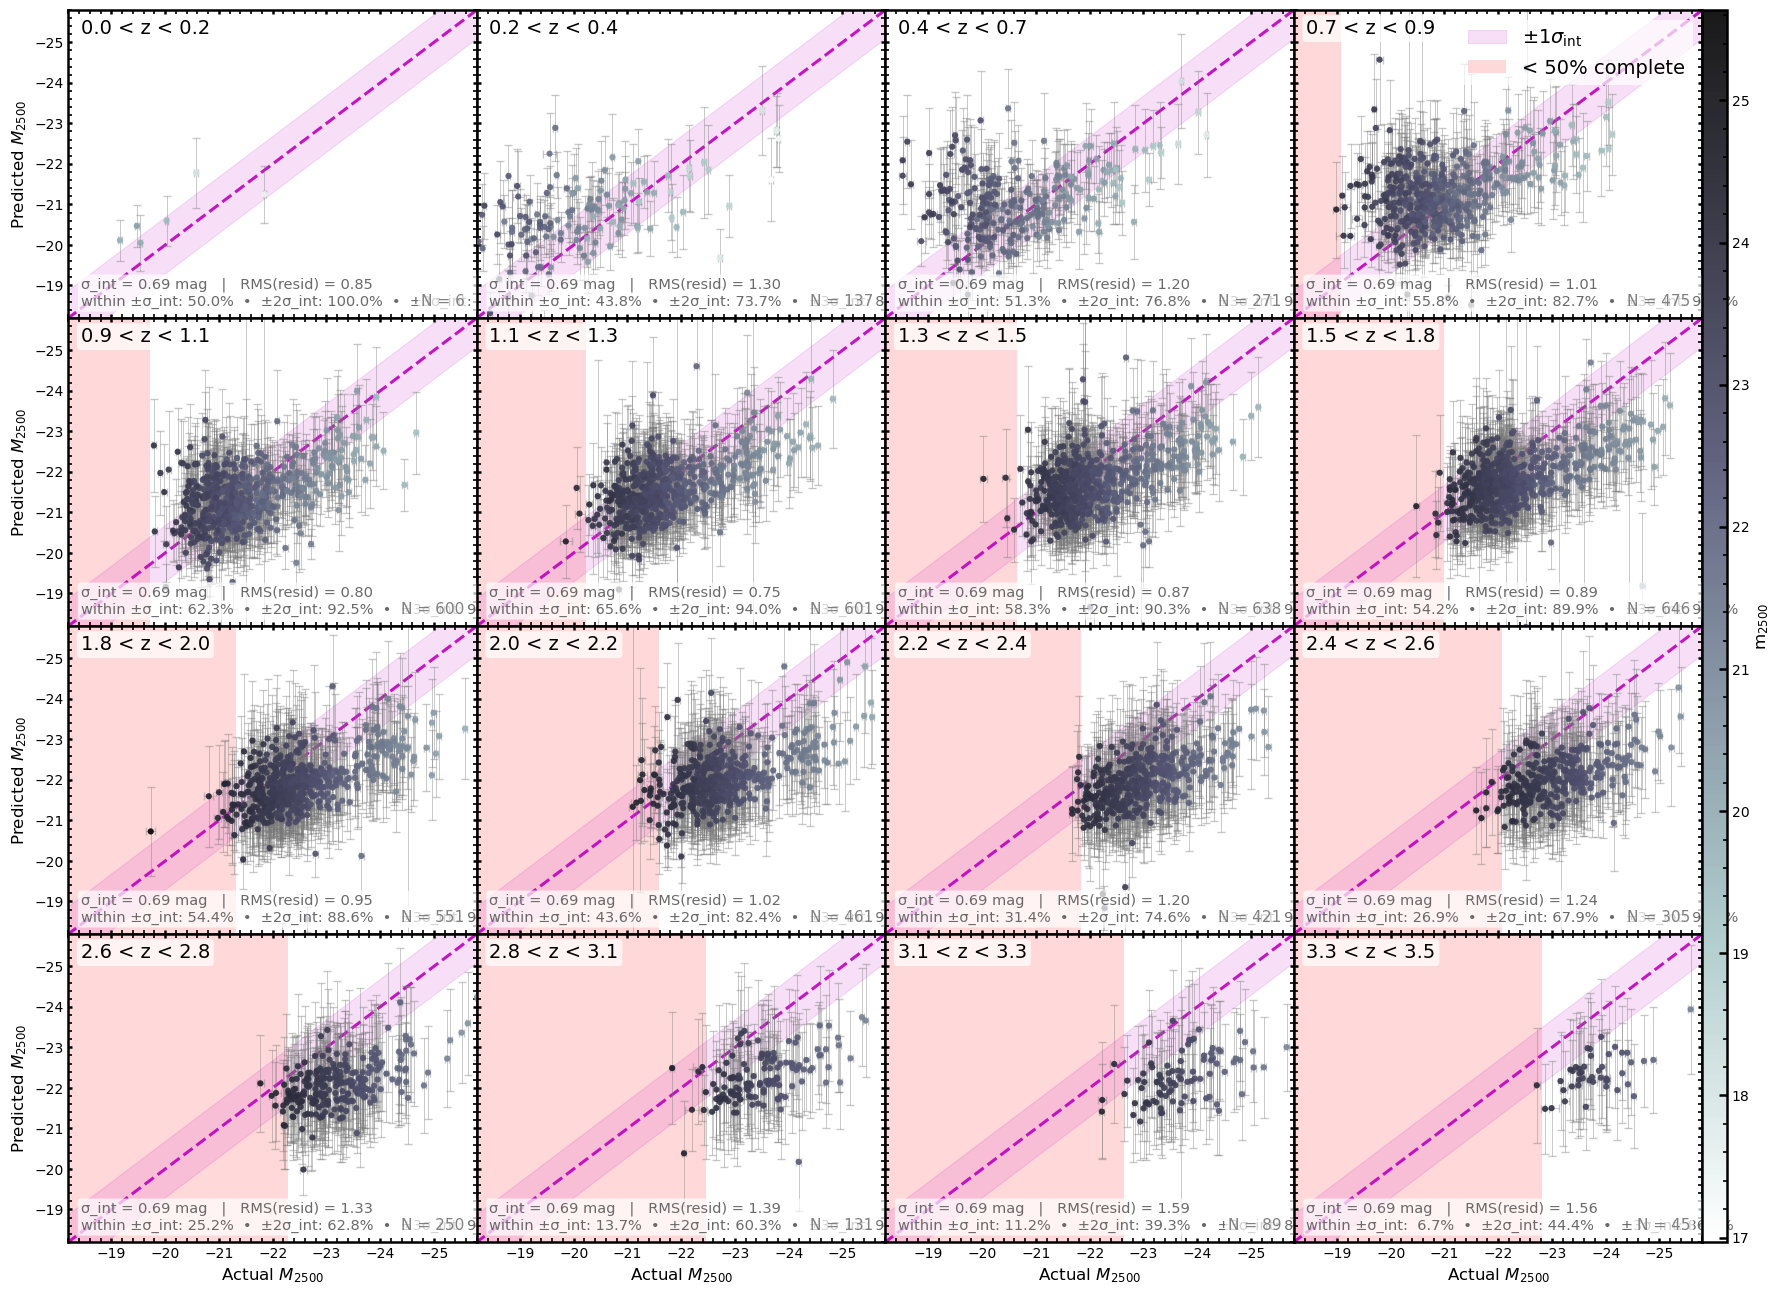

In [101]:
def plot_predicted_vs_actual_M2500(
    flat_samples,
    df_agn,
    cosmo_model,
    z_agn_pivot,
    plot_path="plots/hubble",
    show=False,
    cmap="viridis",       # colormap for points
    box_alpha=0.7,        # transparency of white annotation boxes
    show_sigma_band=True,
    completeness=True,    # add "<50% complete" red region
    m_lim=24.0,           # survey apparent-magnitude limit for completeness shading
    n_cosmo_draws=300,    # posterior draws to propagate cosmology errors (for xerr)
    random_state=42,      # RNG seed for reproducibility of draws
):
    """
    Predicted vs Actual M_2500 with:
      • y-error bars from M_model_agn_err(...)
      • x-error bars = sqrt(apparent_mag_2500_err^2 + sigma_mu_cosmo(z)^2)
      • ±1σ band from intrinsic scatter sigma_int = exp(log_f) (magenta)
      • Per-bin red shaded region "< 50% complete" using bin-center z; shaded area fills
        the entire y-range to the LEFT of the vertical limit (with inverted x-axis).
      • Points colored by m_2500 (no marker outlines), full-height colorbar,
        white translucent annotation boxes.

    Layout: 12 redshift bins arranged as 4 columns × 3 rows.
    """
    import os, math
    import numpy as np
    import matplotlib.pyplot as plt
    from astropy.cosmology import FlatLambdaCDM, FlatwCDM, FlatwpwaCDM

    # --- model parameters from samples ---
    priors, model_labels, model_labels_latex = get_model_params(cosmo_model)
    results = {key: np.percentile(flat_samples[:, i], [16, 50, 84])
               for i, key in enumerate(model_labels)}
    label_to_idx = {k: i for i, k in enumerate(model_labels)}

    # --- intrinsic scatter: sigma_int = exp(log_f) from posterior median ---
    def _find_logf_key(keys):
        lowers = {k.lower(): k for k in keys}
        for cand in ("log_f", "logf", "lnf", "log_sigma_int", "ln_sigma_int"):
            if cand in lowers:
                return lowers[cand]
        for k in keys:
            if "log" in k.lower() and "f" in k.lower():
                return k
        return None
    logf_key = _find_logf_key(results.keys())
    if logf_key is None:
        raise KeyError("Could not find 'log_f' (or variant) among model parameters.")
    sigma_intrinsic = float(np.exp(results[logf_key][1]))

    # --- helpers to build cosmology objects ---
    def _cosmo_from_params(H0, Om0, **kw):
        if cosmo_model == "FlatwCDM":
            return FlatwCDM(H0=H0, Om0=Om0, w0=kw["w0"])
        elif cosmo_model == "Flatw0waCDM":
            return FlatwpwaCDM(H0=H0, Om0=Om0, wp=kw["wp"], wa=kw["wa"], zp=z_agn_pivot)
        elif cosmo_model == "FlatLambdaCDM":
            return FlatLambdaCDM(H0=H0, Om0=Om0)
        else:
            raise ValueError("Invalid cosmology model.")

    # Median cosmology for best-estimate distances
    if cosmo_model == "FlatwCDM":
        cosmo_med = _cosmo_from_params(results["H0"][1], results["Om0"][1], w0=results["w0"][1])
    elif cosmo_model == "Flatw0waCDM":
        cosmo_med = _cosmo_from_params(results["H0"][1], results["Om0"][1],
                                       wp=results["wp"][1], wa=results["wa"][1])
    else:
        cosmo_med = _cosmo_from_params(results["H0"][1], results["Om0"][1])

    # --- data & predictions ---
    z = df_agn["z"].values
    m_app = df_agn["apparent_mag_2500"].values
    if "apparent_mag_2500_err" not in df_agn.columns:
        raise KeyError("df_agn must contain 'apparent_mag_2500_err' for x-error bars.")
    m_app_err = df_agn["apparent_mag_2500_err"].values

    distmod_med = np.array([cosmo_med.distmod(zi).value for zi in z])
    actual_M_2500 = m_app - distmod_med

    M_2500_pred = M_model_agn(
        results["M0_agn"][1],
        results["alpha_agn"][1],
        results["beta_agn"][1],
        results["gamma_agn"][1],
        df_agn["log_sigma_UV"].values,
        df_agn["log_tau_UV_RF"].values,
        df_agn["bwb_beta"].values,
    )

    # --- y-errors from model error propagation ---
    M_2500_pred_err = M_model_agn_err(
        results["M0_agn"][1],
        results["alpha_agn"][1],
        results["beta_agn"][1],
        results["gamma_agn"][1],
        df_agn["log_sigma_UV"].values,
        df_agn["log_sigma_UV_err"].values,
        df_agn["log_tau_UV_RF_err"].values,
        df_agn["bwb_beta_err"].values,
    )
    M_2500_pred_err = np.asarray(M_2500_pred_err, dtype=float)
    M_2500_pred_err[~np.isfinite(M_2500_pred_err) | (M_2500_pred_err < 0)] = np.nan

    # --- x-errors: propagate cosmology posterior into distance modulus ---
    rng = np.random.default_rng(random_state)
    n_samp = flat_samples.shape[0]
    n_draws = min(n_cosmo_draws, n_samp)
    draw_idxs = rng.choice(n_samp, size=n_draws, replace=False) if n_draws < n_samp else np.arange(n_samp)

    def _cosmo_from_draw(row):
        if cosmo_model == "FlatwCDM":
            return FlatwCDM(H0=row[label_to_idx["H0"]], Om0=row[label_to_idx["Om0"]], w0=row[label_to_idx["w0"]])
        elif cosmo_model == "Flatw0waCDM":
            return FlatwpwaCDM(H0=row[label_to_idx["H0"]],
                               Om0=row[label_to_idx["Om0"]],
                               wp=row[label_to_idx["wp"]],
                               wa=row[label_to_idx["wa"]],
                               zp=z_agn_pivot)
        else:
            return FlatLambdaCDM(H0=row[label_to_idx["H0"]], Om0=row[label_to_idx["Om0"]])

    mu_draws = np.empty((n_draws, z.size), dtype=float)
    for j, idx in enumerate(draw_idxs):
        row = flat_samples[idx, :]
        cosmo_j = _cosmo_from_draw(row)
        mu_draws[j, :] = np.array([cosmo_j.distmod(zi).value for zi in z])
    sigma_mu_cosmo = np.nanstd(mu_draws, axis=0, ddof=1)  # per-object DM uncertainty
    xerr = np.sqrt(m_app_err**2 + sigma_mu_cosmo**2)

    # --- binning in redshift ---
    num_cols = 4
    num_rows = 4
    z_bins = np.linspace(0, 3.5, num_cols*num_rows+1)
    z_bin_indices = np.digitize(z, bins=z_bins)
    num_bins = len(z_bins) - 1  # = 12
    bin_labels = [f"{z_bins[i]:.1f} < z < {z_bins[i+1]:.1f}" for i in range(num_bins)]

    # --- figure with full-height colorbar (dedicated column) ---
    fig = plt.figure(figsize=(5 * num_cols + 1.4, 4 * num_rows))
    gs = fig.add_gridspec(num_rows, num_cols + 1,
                          width_ratios=[1]*num_cols + [0.06],
                          wspace=0.0, hspace=0.0)
    axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(num_cols)] for r in range(num_rows)]).flatten()
    cax = fig.add_subplot(gs[:, -1])

    # --- color scaling by m_2500 ---
    vmin, vmax = np.nanmin(m_app), np.nanmax(m_app)

    # --- axis helpers ---
    xlo, xhi = -25.8, -18.2
    ylo, yhi = -25.8, -18.2
    xx = np.linspace(min(xlo, ylo), max(xhi, yhi), 400)

    sc_for_cbar = None

    for i, ax in enumerate(axes):
        ax.set_xlim(xlo, xhi)
        ax.set_ylim(ylo, yhi)

        if i >= num_bins:
            ax.axis("off"); continue

        bin_mask = z_bin_indices == (i + 1)
        if not np.any(bin_mask):
            ax.axis("off"); continue

        x = actual_M_2500[bin_mask]
        y = M_2500_pred[bin_mask]
        xerr_bin = xerr[bin_mask]
        yerr_bin = M_2500_pred_err[bin_mask]
        cvals = m_app[bin_mask]

        # residuals & coverage vs intrinsic sigma
        resid = y - x
        frac1 = 100.0 * np.mean(np.abs(resid) <= 1.0 * sigma_intrinsic)
        frac2 = 100.0 * np.mean(np.abs(resid) <= 2.0 * sigma_intrinsic)
        frac3 = 100.0 * np.mean(np.abs(resid) <= 3.0 * sigma_intrinsic)
        rms_resid = float(np.sqrt(np.nanmean(resid**2))) if resid.size else np.nan

        # error bars (lighter & more transparent for visibility)
        ax.errorbar(
            x, y, xerr=xerr_bin, yerr=yerr_bin,
            fmt="none",
            ecolor="#777777",          # lighter gray
            elinewidth=0.7,            # thinner lines
            alpha=0.4,                 # more transparent
            zorder=2,
        )

        # colored points, no edge (label 'AGN' only once)
        scatter_kwargs = dict(
            c=cvals, cmap=cmap, vmin=vmin, vmax=vmax,
            s=20, alpha=0.9, edgecolors="none", zorder=3,
        )
        if i == 0:
            sc = ax.scatter(x, y, label="AGN", **scatter_kwargs)
        else:
            sc = ax.scatter(x, y, **scatter_kwargs)
        sc_for_cbar = sc

        # y = x reference and ±1σ intrinsic band (MAGENTA)
        ax.plot(xx, xx, color="m", alpha=0.9, lw=2.2, linestyle="--", zorder=1)
        if show_sigma_band:
            ax.fill_between(xx, xx - sigma_intrinsic, xx + sigma_intrinsic,
                            facecolor="m", alpha=0.12, edgecolor="m",
                            lw=0.8, zorder=1, label=r"$\pm 1\sigma_{\rm int}$")

        # "< 50% complete" region in RED — bin-center z; fill entire y-span to the LEFT
        if completeness:
            z_center = 0.5 * (z_bins[i] + z_bins[i+1])
            mu_center = cosmo_med.distmod(z_center).value
            M_lim = m_lim - mu_center
            xmin = max(M_lim, xlo)
            xmax = xhi
            if xmin < xmax:
                ax.axvspan(xmin, xmax, facecolor="red", alpha=0.15, zorder=0, label="< 50% complete")

        # cosmetics
        ax.invert_xaxis()
        ax.invert_yaxis()

        # annotations
        boxprops = dict(boxstyle="round,pad=0.2", facecolor="white", alpha=box_alpha, edgecolor="none")
        ax.annotate(
            bin_labels[i], xy=(0.03, 0.97), xycoords="axes fraction",
            fontsize=14, color="k", ha="left", va="top", bbox=boxprops,
        )
        stats_text = (
            f"σ_int = {sigma_intrinsic:.2f} mag   |   RMS(resid) = {rms_resid:.2f}\n"
            f"within ±σ_int: {frac1:4.1f}%  •  ±2σ_int: {frac2:4.1f}%  •  ±3σ_int: {frac3:4.1f}%"
        )
        ax.annotate(
            stats_text, xy=(0.03, 0.03), xycoords="axes fraction",
            fontsize=10.5, color="dimgray", ha="left", va="bottom", bbox=boxprops,
        )

        n_in_bin = int(np.sum(bin_mask))
        ax.annotate(
            f"N = {n_in_bin}", xy=(0.97, 0.03), xycoords="axes fraction",
            fontsize=11, color="gray", ha="right", va="bottom", bbox=boxprops,
        )

        # labels only on bottom row / left col
        if i >= (num_rows - 1) * num_cols:
            ax.set_xlabel("Actual $M_{2500}$", fontsize=12)
        if i % num_cols == 0:
            ax.set_ylabel("Predicted $M_{2500}$", fontsize=12)
        ax.tick_params(axis="both", labelsize=10, length=3)

        # show legend once (will include AGN + <50% complete + band label)
        if (show_sigma_band or completeness) and i == num_cols-1:
            leg = ax.legend(loc="upper right", fontsize=14, frameon=True)
            leg.get_frame().set_facecolor("white")
            leg.get_frame().set_alpha(box_alpha)
            leg.get_frame().set_edgecolor("none")

    # full-height colorbar
    if sc_for_cbar is not None:
        cbar = fig.colorbar(sc_for_cbar, cax=cax, orientation="vertical")
        cbar.set_label(r"m$_{2500}$", fontsize=12)
        cbar.ax.tick_params(labelsize=10)

    for ax in axes:
        if ax.has_data():
            ax.label_outer()

    os.makedirs(plot_path, exist_ok=True)
    out_path = os.path.join(plot_path, "predicted_vs_actual_M2500.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    plt.close()





plot_predicted_vs_actual_M2500(flat_samples, df_agn, cmap='bone_r', n_cosmo_draws=5,
                               cosmo_model=cosmo_model, z_agn_pivot=z_agn_pivot, show=True, plot_path='plots/test/')

/tmp/ipykernel_124083/2574006633.py:246: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


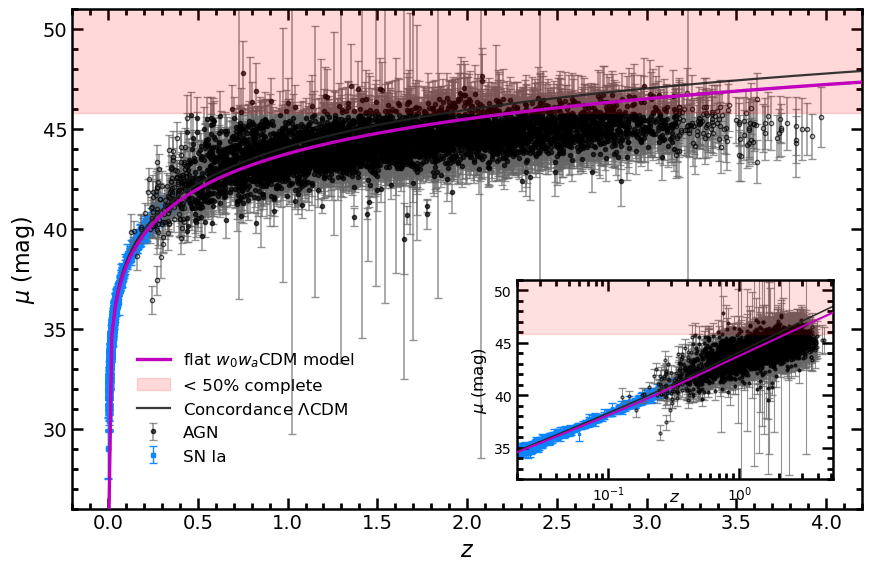

In [ ]:

residuals, mu_pred_median, mu_pred_std = plot_hubble(flat_samples, df_agn, df_pantheon, z_agn_pivot=z_agn_pivot, cosmo_model=cosmo_model, show=True, verbose=False, show_true=False)

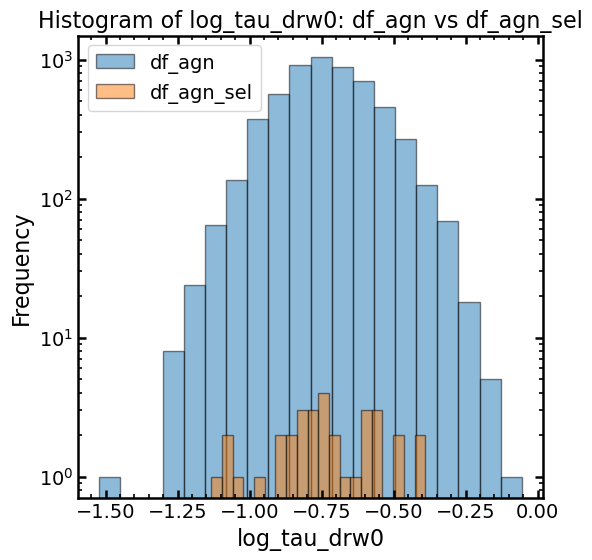

In [44]:
df_agn_sel = df_agn[(np.abs(df_agn['residual']) > 3)]
key = 'log_sigma_UV'
plt.hist(df_agn[key], bins=20, alpha=0.5, label='df_agn', edgecolor='black')
plt.hist(df_agn_sel[key], bins=20, alpha=0.5, label='df_agn_sel', edgecolor='black')
plt.xlabel('log_tau_drw0')
plt.ylabel('Frequency')
plt.title('Histogram of log_tau_drw0: df_agn vs df_agn_sel')
plt.yscale('log')
plt.legend()
plt.show()

3


/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_124083/2574006633.py:246: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


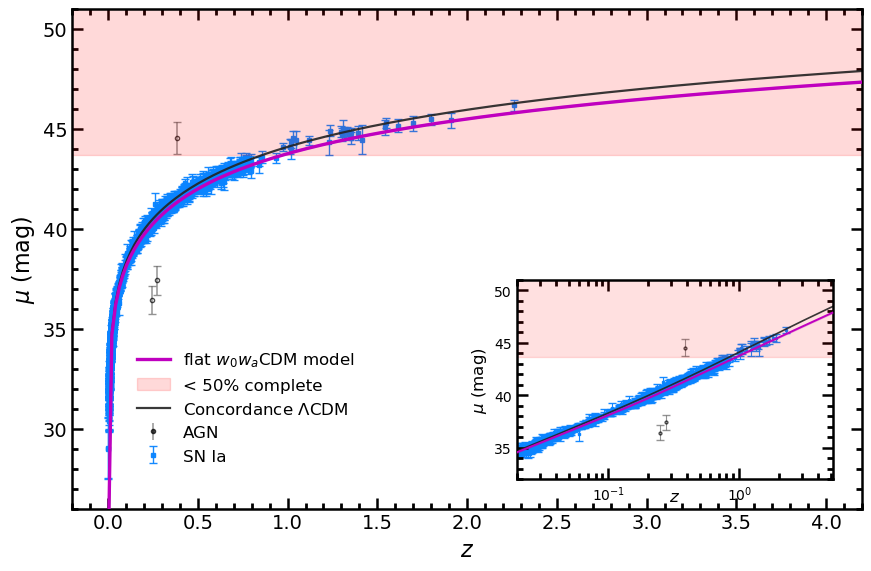

,z,object_id,residual,ra,dec,log_tau_UV_RF,log_tau_drw0,log_sigma_UV
276,0.246641,1391663,-3.775228,40.220118,-0.686367,0.259455,0.355196,-0.583913
786,0.382870,1397617,3.223533,36.061090,0.404312,2.462158,2.602940,-1.085285
1699,0.273765,1413536,-3.047548,24.539755,-1.155627,1.568986,1.674075,-0.706345


In [45]:
df_agn['residual'] = residuals
df_agn['mu_pred_std'] = mu_pred_std

df_agn_sel = df_agn[(np.abs(df_agn['residual']) > 3) & (df_agn['z'] < 0.4)]
#df_agn_sel = df_agn[(df_agn['mu_pred_std'] > 3)]
print(len(df_agn_sel))
_, _, _ = plot_hubble(flat_samples, df_agn_sel, df_pantheon, z_agn_pivot=z_agn_pivot, cosmo_model=cosmo_model, show=True, verbose=False, show_true=False)
df_agn_sel[['z', 'object_id', 'residual', 'ra', 'dec', 'log_tau_UV_RF', 'log_tau_drw0', 'log_sigma_UV']]

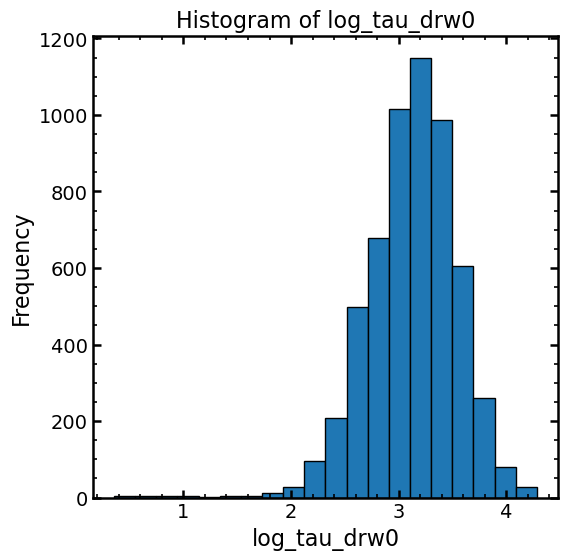

In [30]:
plt.hist(df_agn['log_tau_drw0'], bins=20, edgecolor='black')
plt.xlabel('log_tau_drw0')
plt.ylabel('Frequency')
plt.title('Histogram of log_tau_drw0')
plt.show()

In [19]:
#df_agn['residual'] = residuals
df_agn_sel = df_agn[(df_agn['z'] > 1.4) & (df_agn['z'] < 1.5) & (df_agn['residual'] < -2)]
df_agn_sel[['z', 'object_id', 'residual', 'ra', 'dec', 'log_tau_UV_RF', 'log_sigma_UV']]

,z,object_id,residual,ra,dec,log_tau_UV_RF,log_sigma_UV
149,1.45391,1405466,-3.517596,30.64467,-1.170766,0.456213,-0.883527


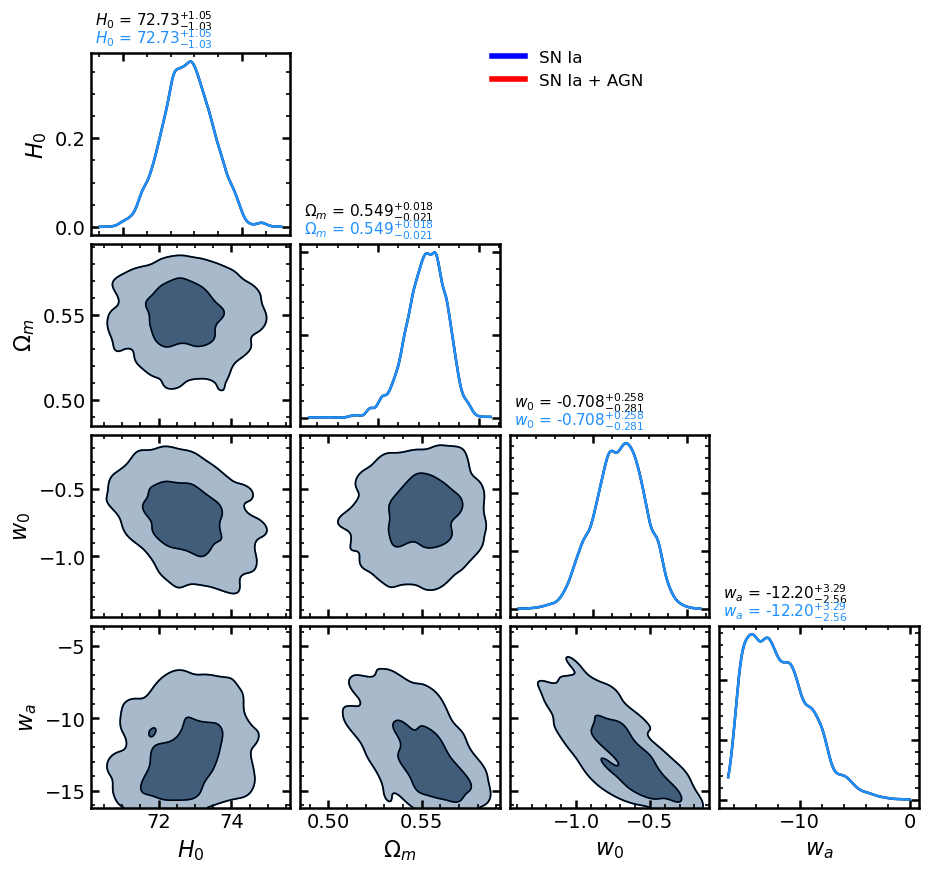

In [17]:
plot_cosmo_corner(flat_samples, flat_samples, cosmo_model=cosmo_model, z_agn_pivot=z_agn_pivot, plot_path="plots/hubble", show=True)

In [83]:
df_agn_sorted = df_agn.assign(mu_pred_std=mu_pred_std)
df_agn_sorted = df_agn_sorted[df_agn_sorted['mu_pred_std'] > 5].sort_values('mu_pred_std', ascending=False)
df_agn_sorted[['object_id', 'z', 'mu_pred_std']]

,object_id,z,mu_pred_std
78,1395656,1.900529,15.997955
154,1406124,1.685036,14.794409
297,1423342,0.693681,14.749796
163,1407986,2.138195,8.786025
215,1413889,2.504551,6.718891
503,1445049,2.276504,6.474745
34,1391845,1.187668,6.066265
203,1412204,1.342666,6.065583
616,1451194,1.268134,6.044926
363,1430274,1.233711,5.320571


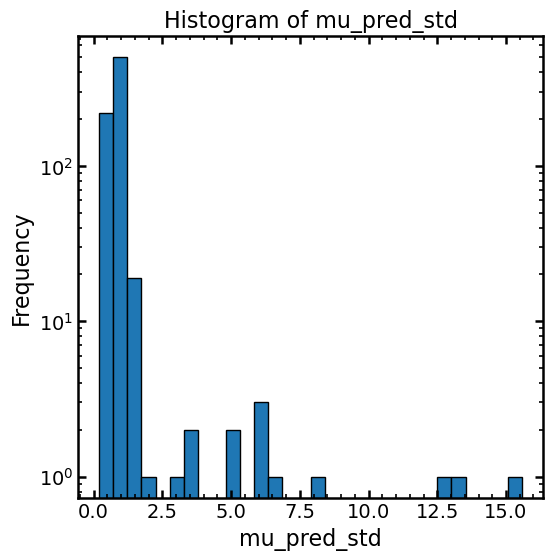

In [8]:
import matplotlib.pyplot as plt

plt.hist(mu_pred_std, bins=30, edgecolor='black')
plt.xlabel('mu_pred_std')
plt.ylabel('Frequency')
plt.yscale('log')
plt.title('Histogram of mu_pred_std')
plt.show()

,object_id,z
34,1391845,1.187668
78,1395656,1.900529
154,1406124,1.685036
163,1407986,2.138195
203,1412204,1.342666
215,1413889,2.504551
237,1416164,0.655224
297,1423342,0.693681
343,1428290,1.027927
363,1430274,1.233711


Reduced chi^2: 9.508


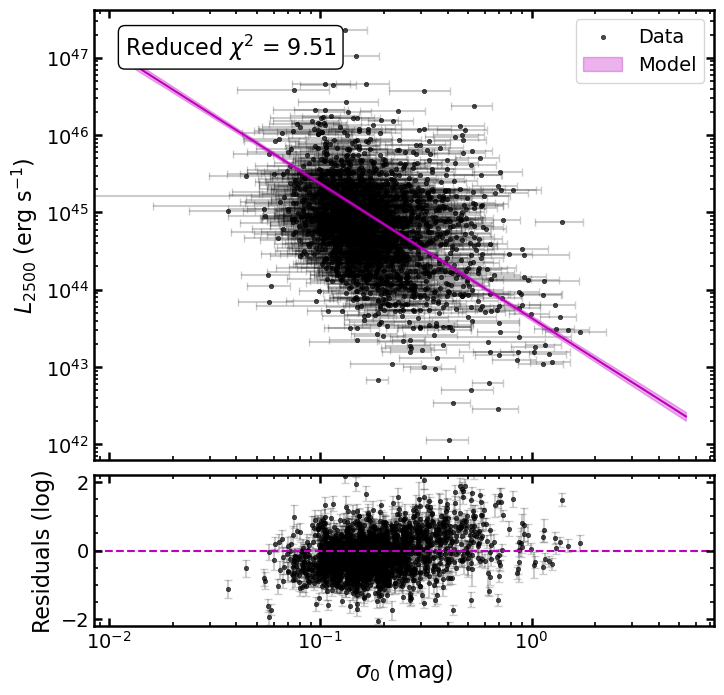

In [10]:
from hubble_plotting import plot_predicted_L2500_vs_sigmahat

plot_predicted_L2500_vs_sigmahat(flat_samples, df_agn, z_agn_pivot=z_agn_pivot, cosmo_model=cosmo_model, show=True)

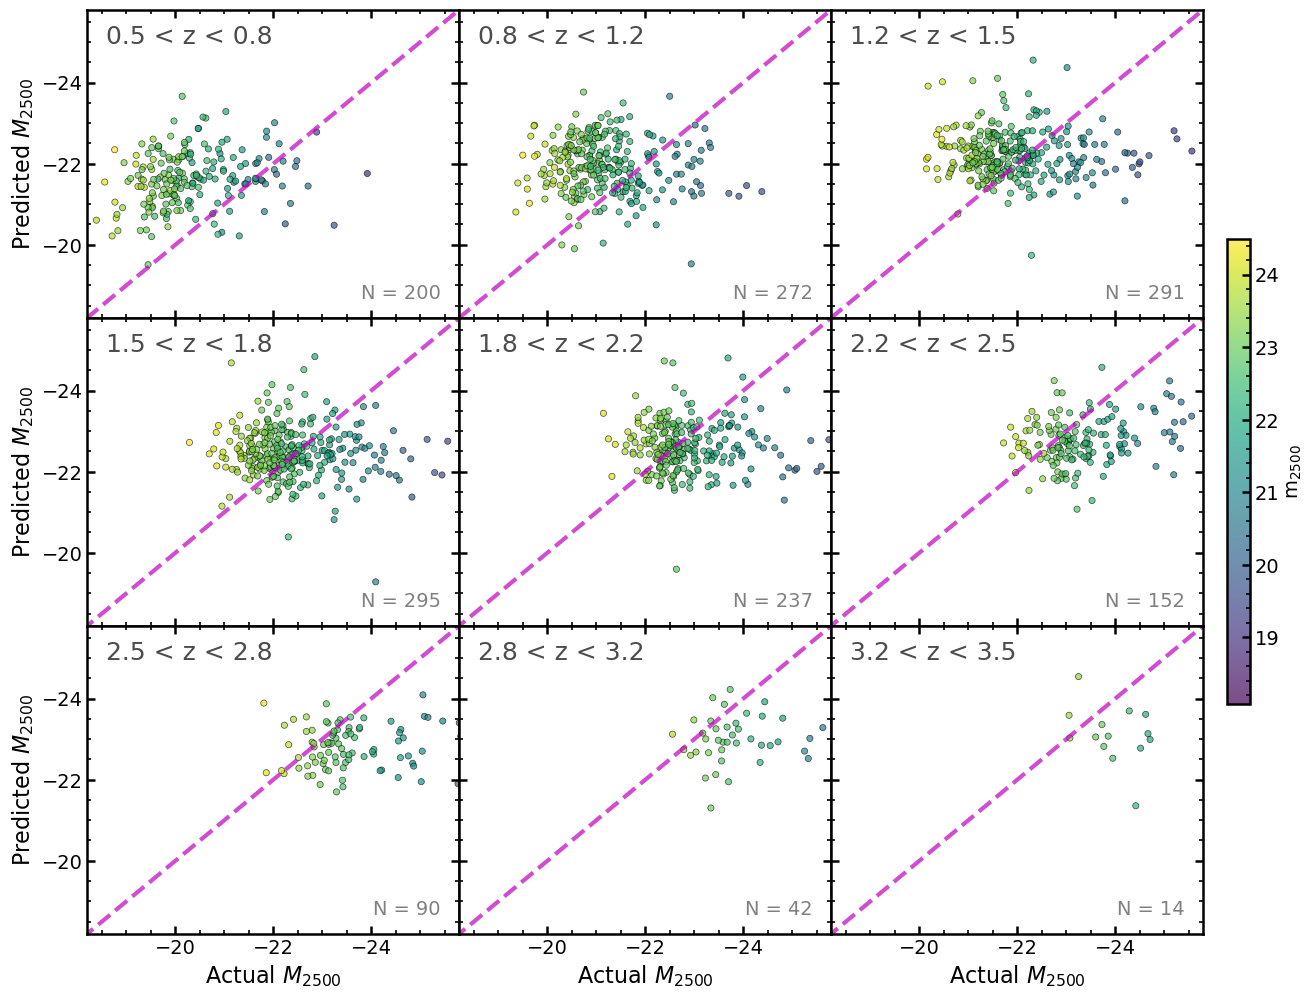

In [12]:
from hubble_plotting import plot_predicted_vs_actual_M2500

plot_predicted_vs_actual_M2500(flat_samples, df_agn, z_agn_pivot=z_agn_pivot, cosmo_model=cosmo_model, show=True)